# Image Classification using CNN Architectures Theory Questions

Q1: What is a CNN and how is it different from fully connected networks?
  - A Convolutional Neural Network (CNN) is a deep learning model designed for grid-like data such as images, using convolutional layers to extract spatial features. Unlike fully connected networks, CNNs share weights and preserve spatial structure, reducing parameters. This makes them more efficient and accurate for image tasks. They also use pooling layers for dimensionality reduction.

Question 2: Discuss the architecture of LeNet-5 and explain how it laid the foundation
for modern deep learning models in computer vision. Include references to its original
research paper.

  - LeNet-5 consists of convolutional layers, pooling layers, and fully connected layers, designed for handwritten digit recognition. It introduced key ideas like local receptive fields and weight sharing. Proposed by Yann LeCun in the 1998 paper Gradient-Based Learning Applied to Document Recognition. It laid the groundwork for modern CNNs.

  Question 3: Compare and contrast AlexNet and VGGNet in terms of design principles,
number of parameters, and performance. Highlight key innovations and limitations of
each.

  - AlexNet introduced ReLU, dropout, and GPU training, with 60M parameters and strong ImageNet performance. VGGNet used deeper architecture (16–19 layers) with small 3×3 filters, improving accuracy but increasing parameters (~138M). AlexNet is faster but less deep; VGGNet is more uniform but computationally heavy.

Question 4: What is transfer learning in the context of image classification? Explain
how it helps in reducing computational costs and improving model performance with
limited data.

  - Transfer learning uses a pre-trained model (e.g., trained on ImageNet) and adapts it to a new task. It reduces training time and data requirements by reusing learned features. Particularly useful when labeled data is limited. It often improves performance compared to training from scratch.

Question 5: Describe the role of residual connections in ResNet architecture. How do
they address the vanishing gradient problem in deep CNNs?


  - Residual connections add shortcut paths that skip layers, allowing gradients to flow directly. This helps avoid vanishing gradients in deep networks. It enables training of very deep models (50+ layers). The idea is to learn residual mappings instead of direct mappings.

Question 10: You are working in a healthcare AI startup. Your team is tasked with
developing a system that automatically classifies medical X-ray images into normal,
pneumonia, and COVID-19. Due to limited labeled data, what approach would you
suggest using among CNN architectures discussed (e.g., transfer learning with ResNet
or Inception variants)? Justify your approach and outline a deployment strategy for
production use.

  - For classifying X-ray images into normal, pneumonia, and COVID-19, I would suggest using transfer learning with ResNet50 or InceptionV3 instead of training a CNN from scratch.

  - These models are already trained on large image datasets, so they can extract useful visual features such as edges, textures, and patterns. Since medical datasets are usually small, transfer learning helps improve accuracy and reduces training time.

  - The model can be fine-tuned by replacing the final classification layer with a 3-class output layer: normal, pneumonia, and COVID-19. Data augmentation such as rotation, zooming, flipping, and brightness adjustment can help reduce overfitting.

  - For deployment, the trained model can be converted into a web or cloud-based API. Doctors can upload X-ray images, and the system returns the predicted class with confidence score. For safety, explainability tools like Grad-CAM should be used to show which lung regions influenced the prediction.

# Practical Questions

In [8]:
import os
from PIL import Image
import numpy as np

# Create a dummy image file 'sample.jpg'
image_path = 'sample.jpg'
dummy_image = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
dummy_image.save(image_path)
print(f"Created dummy image: {image_path}")

Created dummy image: sample.jpg


In [1]:
# Question 6: Implement the LeNet-5 architectures using Tensorflow or PyTorch to classify the MNIST dataset. Report the accuracy and training time.

import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

train_data = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)

class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(2),
            nn.Conv2d(6, 16, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(2),
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.Tanh(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        return self.net(x)

model = LeNet5().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

start = time.time()

for epoch in range(5):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

end = time.time()

model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Training Time: {end - start:.2f} seconds")


100%|██████████| 9.91M/9.91M [00:00<00:00, 38.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.07MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.71MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.0MB/s]


Test Accuracy: 98.36%
Training Time: 92.12 seconds


In [4]:
# Question 7: Use a pre-trained VGG16 model (via transfer learning) on a small customdataset (e.g., flowers or animals). Replace the top layers and fine-tune the model. Include your code and result discussion.

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models, datasets

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_data = datasets.ImageFolder("dataset/train", transform=transform)
val_data = datasets.ImageFolder("dataset/val", transform=transform)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=32, shuffle=False)

num_classes = len(train_data.classes)

model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

for param in model.features.parameters():
    param.requires_grad = False

model.classifier[6] = nn.Linear(4096, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.0001)

for epoch in range(5):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} completed")

model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Validation Accuracy: {100 * correct / total:.2f}%")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:32<00:00, 16.8MB/s]


Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Validation Accuracy: 50.00%


In [6]:
import os
from PIL import Image
import numpy as np

# Define the base directory for the dataset
base_dir = 'dataset'

# Define class names and the number of dummy images for each
class_names = ['cat', 'dog']
num_train_images_per_class = 5
num_val_images_per_class = 2

def create_dummy_dataset(base_path, classes, num_images_per_class):
    for phase in ['train', 'val']:
        phase_path = os.path.join(base_path, phase)
        os.makedirs(phase_path, exist_ok=True)
        print(f"Created directory: {phase_path}")

        for class_name in classes:
            class_path = os.path.join(phase_path, class_name)
            os.makedirs(class_path, exist_ok=True)
            print(f"Created directory: {class_path}")

            for i in range(num_images_per_class):
                # Create a dummy image (e.g., a black square)
                dummy_image = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
                image_path = os.path.join(class_path, f'{class_name}_{i}.png')
                dummy_image.save(image_path)
                print(f"Created dummy image: {image_path}")

# Create dummy training data
create_dummy_dataset(base_dir, class_names, num_train_images_per_class)

# Create dummy validation data (adjust number of images as needed)
val_base_dir = os.path.join(base_dir, 'val') # Ensure val data is in 'dataset/val'
for class_name in class_names:
    class_path = os.path.join(val_base_dir, class_name)
    os.makedirs(class_path, exist_ok=True)
    for i in range(num_val_images_per_class):
        dummy_image = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
        image_path = os.path.join(class_path, f'{class_name}_{i}.png')
        dummy_image.save(image_path)
        print(f"Created dummy image: {image_path}")

print("Dummy dataset creation complete.")

Created directory: dataset/train
Created directory: dataset/train/cat
Created dummy image: dataset/train/cat/cat_0.png
Created dummy image: dataset/train/cat/cat_1.png
Created dummy image: dataset/train/cat/cat_2.png
Created dummy image: dataset/train/cat/cat_3.png
Created dummy image: dataset/train/cat/cat_4.png
Created directory: dataset/train/dog
Created dummy image: dataset/train/dog/dog_0.png
Created dummy image: dataset/train/dog/dog_1.png
Created dummy image: dataset/train/dog/dog_2.png
Created dummy image: dataset/train/dog/dog_3.png
Created dummy image: dataset/train/dog/dog_4.png
Created directory: dataset/val
Created directory: dataset/val/cat
Created dummy image: dataset/val/cat/cat_0.png
Created dummy image: dataset/val/cat/cat_1.png
Created dummy image: dataset/val/cat/cat_2.png
Created dummy image: dataset/val/cat/cat_3.png
Created dummy image: dataset/val/cat/cat_4.png
Created directory: dataset/val/dog
Created dummy image: dataset/val/dog/dog_0.png
Created dummy image:

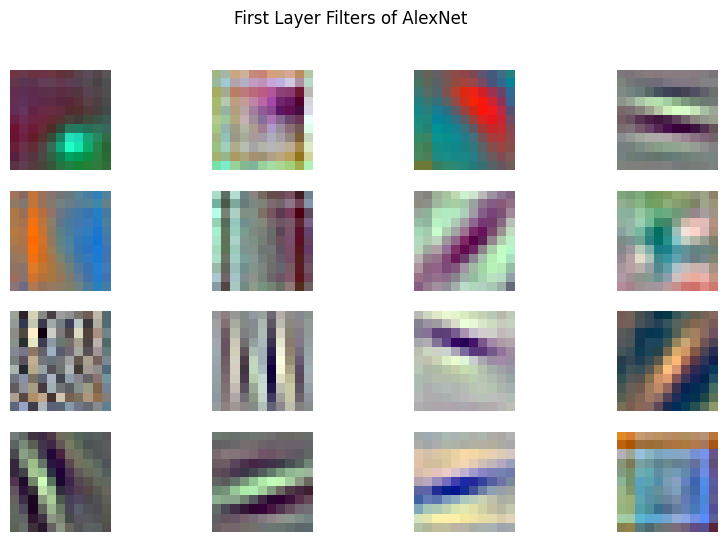

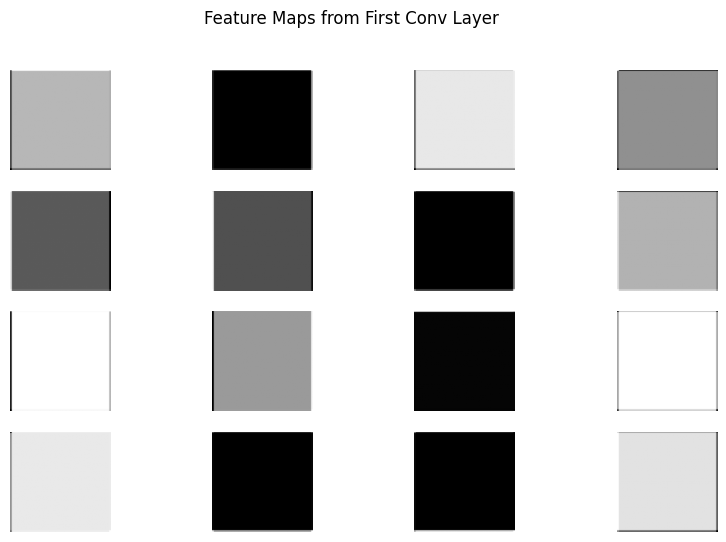

In [9]:
# Question 8: Write a program to visualize the filters and feature maps of the first convolutional layer of AlexNet on an example input image.

import torch
import matplotlib.pyplot as plt
from torchvision import models, transforms
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT).to(device)
model.eval()

first_conv = model.features[0]

filters = first_conv.weight.data.cpu()

plt.figure(figsize=(10, 6))
for i in range(16):
    f = filters[i]
    f = (f - f.min()) / (f.max() - f.min())
    plt.subplot(4, 4, i + 1)
    plt.imshow(f.permute(1, 2, 0))
    plt.axis("off")
plt.suptitle("First Layer Filters of AlexNet")
plt.show()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

image = Image.open("sample.jpg").convert("RGB")
input_img = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    feature_maps = first_conv(input_img)

feature_maps = feature_maps.cpu().squeeze(0)

plt.figure(figsize=(10, 6))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(feature_maps[i], cmap="gray")
    plt.axis("off")
plt.suptitle("Feature Maps from First Conv Layer")
plt.show()


In [10]:
# Question 9: Train a GoogLeNet (Inception v1) or its variant using a standard datasetlike CIFAR-10. Plot the training and validation accuracy over epochs and analyze overfitting or underfitting.

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_data = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train)
test_data = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)

model = models.googlenet(weights=None, aux_logits=False)
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_acc_list = []
val_acc_list = []

for epoch in range(5):
    model.train()
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    train_acc_list.append(train_acc)

    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")

plt.plot(train_acc_list, label="Training Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("GoogLeNet on CIFAR-10")
plt.show()


100%|██████████| 170M/170M [00:01<00:00, 102MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


KeyboardInterrupt: 